In [1]:
import pandas as pd
import numpy as np 
import warnings

In [2]:
warnings.filterwarnings('ignore')

In [3]:
data=pd.read_csv('C:/Users/THREE STARS/Downloads/bank-additional-full.csv', sep=';',skipinitialspace=True)

In [4]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
data.shape

(41188, 21)

In [6]:
data.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [7]:
data.duplicated().any()

True

In [8]:
data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [9]:
data.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [11]:
data[data.duplicated()]

# not necessary removing the duplicates because some customers in the bank shares almost same info

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
20216,55,services,married,high.school,unknown,no,no,cellular,aug,mon,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
20534,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
25217,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no


In [12]:
data.nunique()

age                 78
job                 12
marital              4
education            8
default              3
housing              3
loan                 3
contact              2
month               10
day_of_week          5
duration          1544
campaign            42
pdays               27
previous             8
poutcome             3
emp.var.rate        10
cons.price.idx      26
cons.conf.idx       26
euribor3m          316
nr.employed         11
y                    2
dtype: int64

In [13]:
data.corr()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,-0.000866,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725
duration,-0.000866,1.000000,-0.071699,-0.047577,0.020640,-0.027968,0.005312,-0.008173,-0.032897,-0.044703
campaign,0.004594,-0.071699,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095
pdays,-0.034369,-0.047577,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605
previous,0.024365,0.020640,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333
emp.var.rate,-0.000371,-0.027968,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970
cons.price.idx,0.000857,0.005312,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034
cons.conf.idx,0.129372,-0.008173,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513
euribor3m,0.010767,-0.032897,0.135133,0.296899,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154
nr.employed,-0.017725,-0.044703,0.144095,0.372605,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Correlation Matrix')

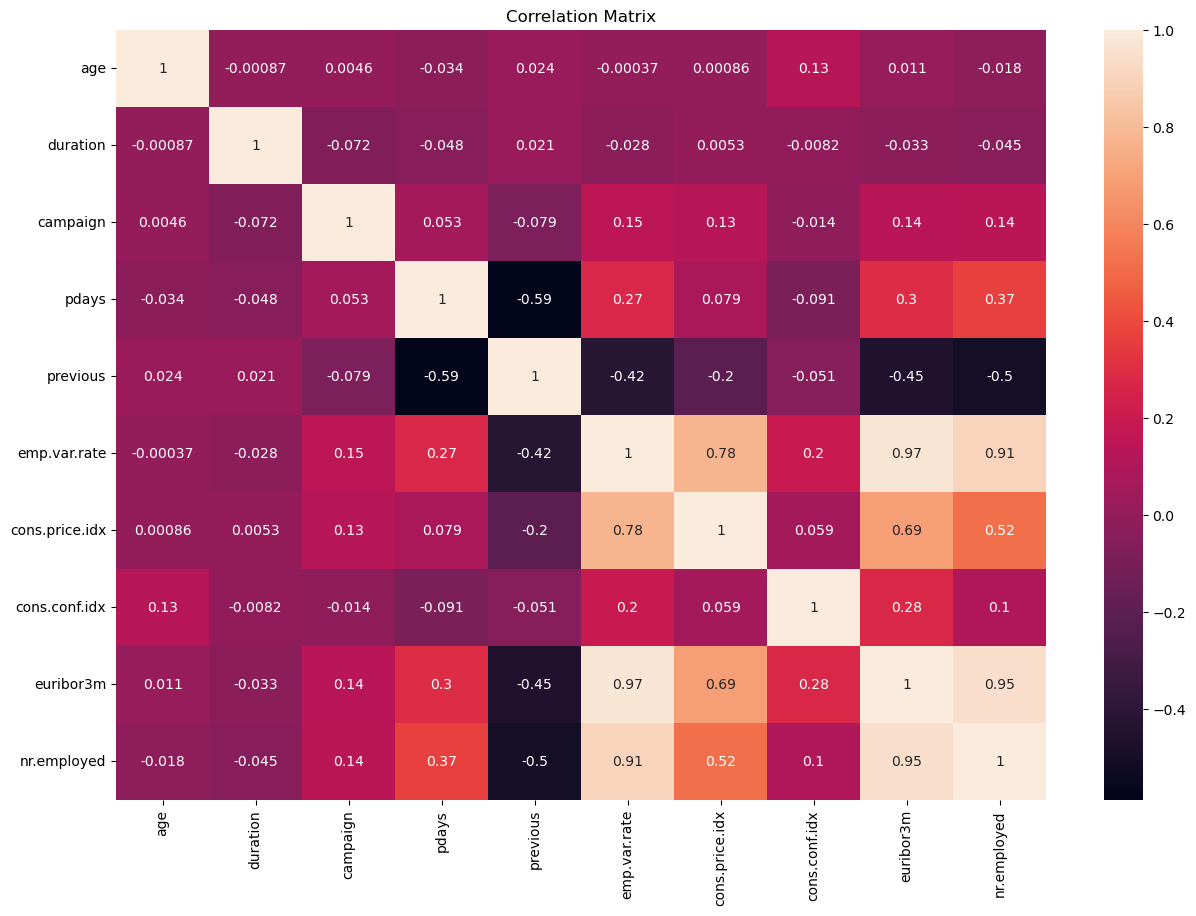

In [15]:
plt.figure(figsize=(15,10))
sns.heatmap(data.corr(),annot=True)
plt.title('Correlation Matrix')

In [16]:
data.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


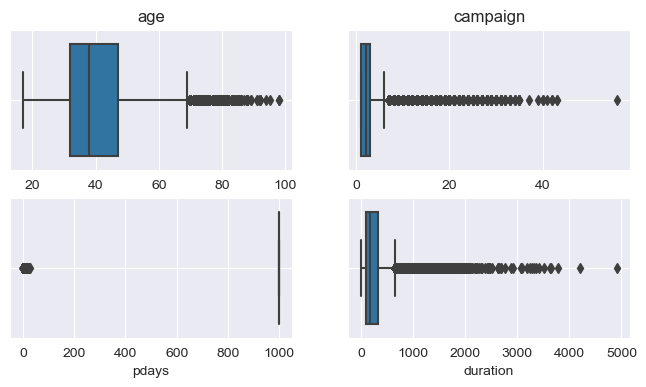

In [17]:
sns.set_style('darkgrid')
fig,axes=plt.subplots(2,2,figsize=(8,4))
plt.subplot(2,2,1)
sns.boxplot(data['age'])
plt.title('age')
plt.grid(True)

plt.subplot(2,2,2)
sns.boxplot(data['campaign'])
plt.title('campaign')
plt.grid(True)

plt.subplot(2,2,3)
sns.boxplot(data['pdays'])
plt.grid(True)

plt.subplot(2,2,4)
sns.boxplot(data['duration'])
plt.grid(True)

plt.show()

In [18]:
data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [19]:
Q1=data.quantile(0.25)
Q3=data.quantile(0.75)
IQR=Q3-Q1
print(f'inter_quatile_range:\n {IQR}')

inter_quatile_range:
 age                15.000
duration          217.000
campaign            2.000
pdays               0.000
previous            0.000
emp.var.rate        3.200
cons.price.idx      0.919
cons.conf.idx       6.300
euribor3m           3.617
nr.employed       129.000
dtype: float64


In [20]:
# removing otliers

data=data[~((data< (Q1-1.5*IQR))|(data>(Q3+1.5*IQR)))]

In [21]:
data.shape

(41188, 21)

In [22]:
col_list=list(data.columns)

In [23]:
col_list

['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'y']

In [24]:
data['age'].mode()[0]

31.0

In [25]:
for col in col_list:
    if data[col].dtypes=='object':
        data[col]=data[col].fillna(data[col].mode()[0])
    else:
        data[col]=data[col].fillna(data[col].mean())

In [26]:
data.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [27]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# encoding the label to binary format

In [28]:
from sklearn.preprocessing import LabelEncoder

In [29]:
labelencoder=LabelEncoder()

In [30]:
for i in col_list:
    data[i]=labelencoder.fit_transform(data[i])

In [31]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,40,3,1,0,0,0,0,1,6,1,...,0,0,0,1,8,18,17,287,8,0
1,41,7,1,3,1,0,0,1,6,1,...,0,0,0,1,8,18,17,287,8,0
2,20,7,1,3,0,2,0,1,6,1,...,0,0,0,1,8,18,17,287,8,0
3,24,0,1,1,0,0,0,1,6,1,...,0,0,0,1,8,18,17,287,8,0
4,40,7,1,3,0,0,2,1,6,1,...,0,0,0,1,8,18,17,287,8,0


In [32]:
data.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,23,5,1,5,0,2,0,0,7,0,...,0,0,0,1,5,25,0,171,0,1
41184,30,1,1,5,0,0,0,0,7,0,...,0,0,0,1,5,25,0,171,0,0
41185,40,5,1,6,0,2,0,0,7,0,...,1,0,0,1,5,25,0,171,0,0
41186,28,9,1,5,0,0,0,0,7,0,...,0,0,0,1,5,25,0,171,0,1
41187,23,5,1,5,0,2,0,0,7,0,...,3,0,0,0,5,25,0,171,0,0


In [33]:
data['job'].value_counts()

0     10422
1      9254
9      6743
7      3969
4      2924
5      1720
2      1456
6      1421
3      1060
10     1014
8       875
11      330
Name: job, dtype: int64

In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             41188 non-null  int64
 1   job             41188 non-null  int32
 2   marital         41188 non-null  int32
 3   education       41188 non-null  int32
 4   default         41188 non-null  int32
 5   housing         41188 non-null  int32
 6   loan            41188 non-null  int32
 7   contact         41188 non-null  int32
 8   month           41188 non-null  int32
 9   day_of_week     41188 non-null  int32
 10  duration        41188 non-null  int64
 11  campaign        41188 non-null  int64
 12  pdays           41188 non-null  int64
 13  previous        41188 non-null  int64
 14  poutcome        41188 non-null  int32
 15  emp.var.rate    41188 non-null  int64
 16  cons.price.idx  41188 non-null  int64
 17  cons.conf.idx   41188 non-null  int64
 18  euribor3m       41188 non-

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

col_list=[]

for col in data.columns:
    if ((data[col].dtype != 'object') & (col != 'y')):
        col_list.append(col)
        
x=data[col_list]
vif_data=pd.DataFrame()
vif_data['features']=x.columns
vif_data['vif']=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif_data

,features,vif
0,age,7.132112
1,job,2.105892
2,marital,5.234357
3,education,4.319965
4,default,1.406598
5,housing,2.175447
6,loan,1.206807
7,contact,3.097743
8,month,4.591461
9,day_of_week,3.048572


In [36]:
data=data.drop(['nr.employed'],axis=1)

In [37]:
col_list=[]

for col in data.columns:
    if ((data[col].dtype != 'object') & (col != 'y')):
        col_list.append(col)
        
x=data[col_list]
vif_data=pd.DataFrame()
vif_data['features']=x.columns
vif_data['vif']=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif_data

,features,vif
0,age,6.839205
1,job,2.104191
2,marital,5.090619
3,education,4.288045
4,default,1.406574
5,housing,2.171051
6,loan,1.206072
7,contact,3.048997
8,month,4.587273
9,day_of_week,3.039238


In [38]:
data=data.drop(['euribor3m'],axis=1)

In [39]:
col_list=[]

for col in data.columns:
    if ((data[col].dtype != 'object') & (col != 'y')):
        col_list.append(col)
        
x=data[col_list]
vif_data=pd.DataFrame()
vif_data['features']=x.columns
vif_data['vif']=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif_data

,features,vif
0,age,5.999433
1,job,2.093585
2,marital,4.548491
3,education,4.164142
4,default,1.402847
5,housing,2.135178
6,loan,1.203070
7,contact,3.009706
8,month,4.359532
9,day_of_week,2.985342


In [40]:
data=data.drop(['cons.price.idx'],axis=1)

In [41]:
col_list=[]

for col in data.columns:
    if ((data[col].dtype != 'object') & (col != 'y')):
        col_list.append(col)
        
x=data[col_list]
vif_data=pd.DataFrame()
vif_data['features']=x.columns
vif_data['vif']=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif_data

,features,vif
0,age,5.896526
1,job,2.089968
2,marital,4.449895
3,education,4.151644
4,default,1.402813
5,housing,2.134379
6,loan,1.202734
7,contact,2.215740
8,month,4.314930
9,day_of_week,2.983514


In [42]:
data=data.drop(['cons.conf.idx'],axis=1)

In [43]:
col_list=[]

for col in data.columns:
    if ((data[col].dtype != 'object') & (col != 'y')):
        col_list.append(col)
        
x=data[col_list]
vif_data=pd.DataFrame()
vif_data['features']=x.columns
vif_data['vif']=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif_data

,features,vif
0,age,5.712338
1,job,2.082385
2,marital,4.425259
3,education,4.062328
4,default,1.402593
5,housing,2.133826
6,loan,1.202730
7,contact,2.092399
8,month,4.296250
9,day_of_week,2.970857


In [44]:
data=data.drop(['pdays','previous'],axis=1)

In [45]:
col_list=[]

for col in data.columns:
    if ((data[col].dtype != 'object') & (col != 'y')):
        col_list.append(col)
        
x=data[col_list]
vif_data=pd.DataFrame()
vif_data['features']=x.columns
vif_data['vif']=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif_data

,features,vif
0,age,5.712338
1,job,2.082385
2,marital,4.425259
3,education,4.062328
4,default,1.402593
5,housing,2.133826
6,loan,1.202730
7,contact,2.092399
8,month,4.296250
9,day_of_week,2.970857


In [46]:
data=data.drop(['age'],axis=1)

In [47]:
col_list=[]

for col in data.columns:
    if ((data[col].dtype != 'object') & (col != 'y')):
        col_list.append(col)
        
x=data[col_list]
vif_data=pd.DataFrame()
vif_data['features']=x.columns
vif_data['vif']=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif_data

,features,vif
0,job,2.069674
1,marital,4.263234
2,education,3.999938
3,default,1.350523
4,housing,2.108194
5,loan,1.201515
6,contact,2.077225
7,month,4.051045
8,day_of_week,2.946825
9,duration,3.014885


In [48]:
vif_data

,features,vif
0,job,2.069674
1,marital,4.263234
2,education,3.999938
3,default,1.350523
4,housing,2.108194
5,loan,1.201515
6,contact,2.077225
7,month,4.051045
8,day_of_week,2.946825
9,duration,3.014885


In [49]:
ind_features=vif_data['features']
ind_features

0              job
1          marital
2        education
3          default
4          housing
5             loan
6          contact
7            month
8      day_of_week
9         duration
10        campaign
11        poutcome
12    emp.var.rate
Name: features, dtype: object

In [50]:
df_ind=list(ind_features)
df_ind

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'poutcome',
 'emp.var.rate']

In [51]:
df_features=data[df_ind]

In [52]:
x=df_features
y=data['y']

In [53]:
y.ndim

1

In [54]:
x.dtypes

job             int32
marital         int32
education       int32
default         int32
housing         int32
loan            int32
contact         int32
month           int32
day_of_week     int32
duration        int64
campaign        int64
poutcome        int32
emp.var.rate    int64
dtype: object

In [55]:
y.dtypes

dtype('int32')

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)


In [58]:
X_train.shape

(30891, 13)

In [59]:
y_test.shape

(10297,)

In [60]:
from sklearn.linear_model import LogisticRegression

In [61]:
model=LogisticRegression()

In [62]:
model.fit(X_train,y_train)

LogisticRegression()

In [63]:
test_pred=model.predict(X_test)

In [64]:
test_pred

array([0, 0, 0, ..., 0, 0, 0])

In [65]:
from sklearn.metrics import confusion_matrix,accuracy_score

In [66]:
confusion_matrix(y_test,test_pred)

array([[8989,  150],
       [ 950,  208]], dtype=int64)

In [67]:
TP=9061
FP=1032
TN=126
FN=78

precision=TP/(TP+FP)
Recall=TP/(TP+FN)
F1_score= 2*(precision*Recall)/(precision+Recall)


In [68]:
print(f'The precision is {precision * 100}\nRecall is {Recall*100}\n F1 score is {F1_score*100}')

The precision is 89.7750916476766
Recall is 99.14651493598862
 F1 score is 94.2283693843594


In [69]:
accuracy_score(y_test,test_pred)

0.8931727687676022

In [70]:
from sklearn.ensemble import RandomForestClassifier

In [71]:
rd=RandomForestClassifier(n_estimators=250)

In [72]:
forest=rd.fit(X_train,y_train)

In [73]:
test_pred=forest.predict(X_test)

In [74]:
test_pred

array([0, 0, 0, ..., 0, 0, 0])

In [75]:
accuracy_score(test_pred,y_test)

0.9082256968048946